In [51]:
from notebooks/transform_plotter import pipeline, single_wavelet, plotter, reduce, read_sim
import butterpy as bp
import lightkurve as lk
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import os
from pyasassn.client import SkyPatrolClient

In [35]:
client = SkyPatrolClient()

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.19 (22 MAY 2025)
Please upgrade your client if not up to date.

We are reprocessing a number of lightcurves in database.
Once finished we should have more complete and higher quality photometry.
Thank you for your patience,
K. Hart (22 MAY 2025)




Pulled 1 of 1


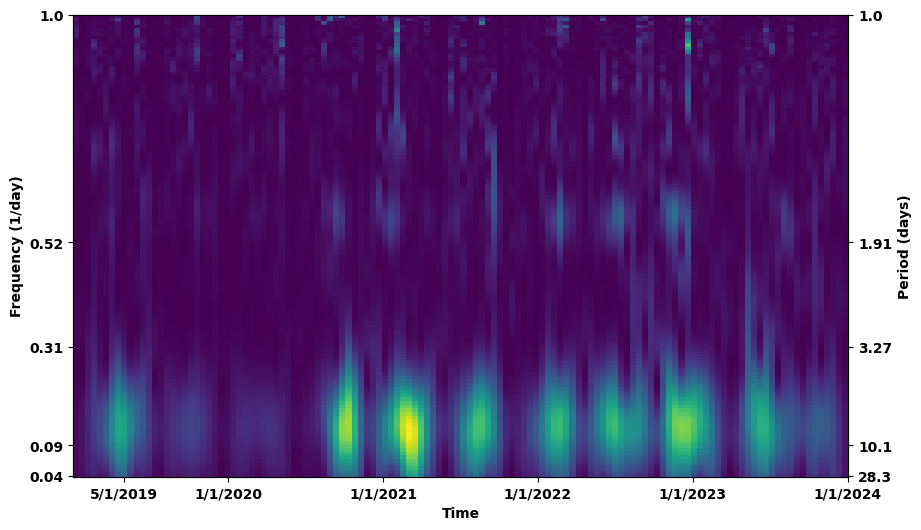

In [71]:
wavelet = pipeline(463856975202)
objectlightcurve = reduce(wavelet)

In [72]:
simulation_file = "(#save location of sim file#)"
simulation = read_sim(simulation_file)
newflux = inject_flux(simulation, objectlightcurve)

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_13722/2549922193.py:22: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


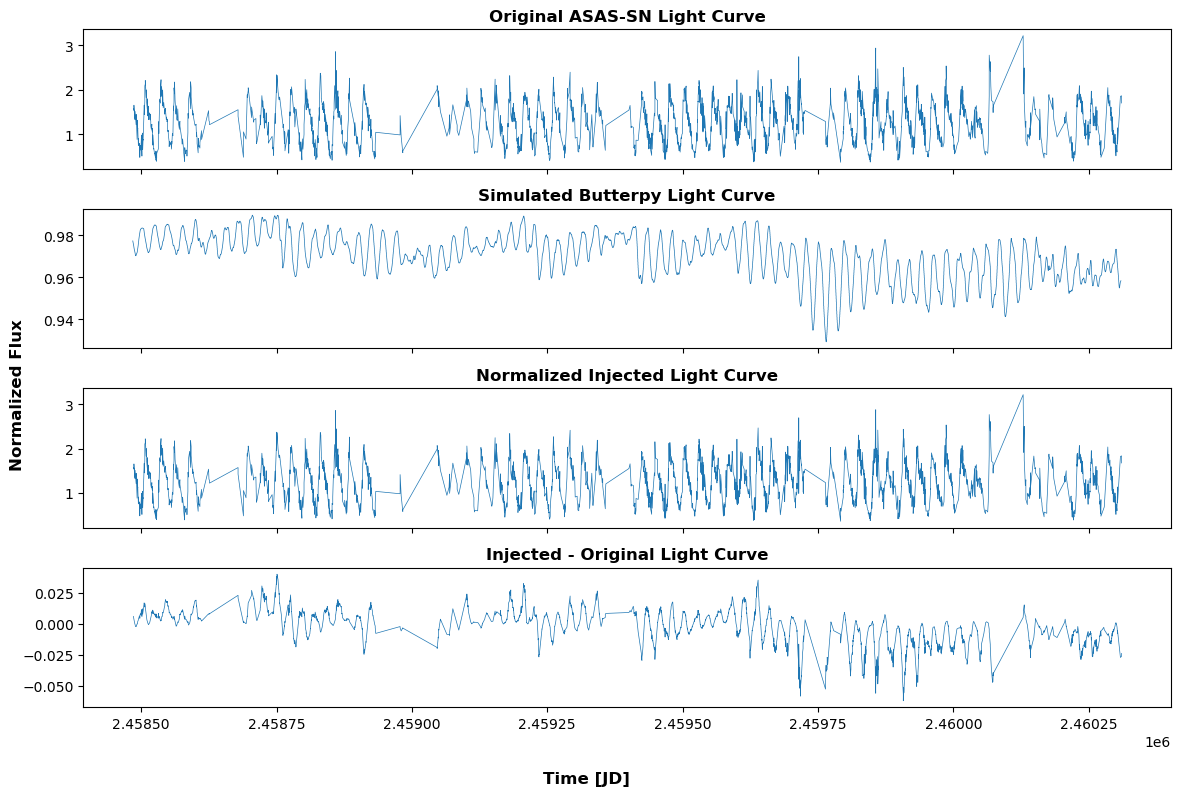

In [76]:
plt.rcParams.update({'font.size': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10})
fig, [ax1, ax2, ax3, ax4] = plt.subplots(figsize=(12, 8), ncols = 1, nrows = 4, constrained_layout=True, sharex=True)

ax1.set_title("Original ASAS-SN Light Curve", weight='bold', size=12)
noiseylc = lk.LightCurve(time=objectlightcurve.jd, flux=objectlightcurve.flux)
noiseylc.plot(ax=ax1, xlabel="", ylabel="")

ax2.set_title("Simulated Butterpy Light Curve", weight='bold', size=12)
new_sim_lc = lk.LightCurve(time=simulation.time, flux=simulation.flux)
new_sim_lc.plot(ax = ax2, xlabel="", ylabel="")

ax3.set_title("Normalized Injected Light Curve", weight='bold', size=12)
new_sim_lc2 = lk.LightCurve(time=objectlightcurve.jd, flux=newflux)
new_sim_lc2.plot(ax = ax3, xlabel="", ylabel="")

ax4.set_title("Injected - Original Light Curve", weight='bold', size=12)
new_sim_lc3 = lk.LightCurve(time=objectlightcurve.jd, flux=(newflux-objectlightcurve.flux))
new_sim_lc3.plot(ax = ax4, xlabel="", ylabel="")

fig.supylabel('Normalized Flux', weight='bold')
fig.supxlabel('Time [JD]', weight='bold')
fig.tight_layout()